Roll No.: 10

Name: Shubham Khairnar

Date of Performance: 18 Mar 2026

Problem Statement: Implement a policy gradient algorithms like REINFORCE or Proximal Policy Optimization (PPO)
to solve a continuous control task.


In [ ]:
!pip install gymnasium torch numpy matplotlib

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import Normal

In [ ]:
class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.actor = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, action_dim),
            nn.Tanh()
        )

        self.critic = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

        self.log_std = nn.Parameter(torch.zeros(action_dim))

    def forward(self, state):
        mean = self.actor(state)
        std = torch.exp(self.log_std).clamp(1e-3, 1.0)
        dist = Normal(mean, std)
        value = self.critic(state)
        return dist, value

In [ ]:
class PPO:
    def __init__(self, state_dim, action_dim):
        self.model = ActorCritic(state_dim, action_dim)
        self.optimizer = optim.Adam(self.model.parameters(), lr=3e-4)

        self.gamma = 0.99
        self.lam = 0.95
        self.eps_clip = 0.2
        self.K_epochs = 20

    def select_action(self, state, action_low, action_high):
        state = torch.FloatTensor(state)
        dist, value = self.model(state)

        action = dist.sample()
        log_prob = dist.log_prob(action).sum()

        # Scale action [-1,1] → [low, high]
        action_scaled = action * ((action_high - action_low)/2) + (action_high + action_low)/2
        action_clipped = torch.clamp(action_scaled, action_low, action_high)

        return action_clipped.detach().numpy(), log_prob.detach(), value.detach()

    def update(self, states, actions, log_probs_old, rewards, values, dones):
        # ----- GAE -----
        advantages = []
        gae = 0
        values = values + [0]

        for t in reversed(range(len(rewards))):
            delta = rewards[t] + self.gamma * values[t+1] * (1 - dones[t]) - values[t]
            gae = delta + self.gamma * self.lam * (1 - dones[t]) * gae
            advantages.insert(0, gae)

        advantages = np.array(advantages)
        returns = advantages + np.array(values[:-1])

        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        states = torch.FloatTensor(states)
        actions = torch.FloatTensor(actions)
        log_probs_old = torch.stack(log_probs_old)
        returns = torch.FloatTensor(returns)
        advantages = torch.FloatTensor(advantages)

        # ----- PPO Update -----
        batch_size = 64

        for _ in range(self.K_epochs):
            idx = np.random.permutation(len(states))

            for i in range(0, len(states), batch_size):
                batch_idx = idx[i:i+batch_size]

                dist, values_new = self.model(states[batch_idx])

                log_probs = dist.log_prob(actions[batch_idx]).sum(dim=1)
                entropy = dist.entropy().sum(dim=1).mean()

                ratios = torch.exp(log_probs - log_probs_old[batch_idx])

                surr1 = ratios * advantages[batch_idx]
                surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages[batch_idx]

                actor_loss = -torch.min(surr1, surr2).mean()
                critic_loss = (returns[batch_idx] - values_new.squeeze()).pow(2).mean()

                loss = actor_loss + 0.5 * critic_loss - 0.01 * entropy

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

In [ ]:
env = gym.make("Pendulum-v1")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]

action_low = env.action_space.low[0]
action_high = env.action_space.high[0]

agent = PPO(state_dim, action_dim)

episodes = 300
update_timestep = 2048

states, actions, log_probs, rewards, values, dones = [], [], [], [], [], []
scores = []
timestep = 0

for ep in range(episodes):
    state, _ = env.reset()
    total_reward = 0

    while True:
        action, log_prob, value = agent.select_action(state, action_low, action_high)

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        states.append(state)
        actions.append(action)
        log_probs.append(log_prob)
        rewards.append(reward)
        values.append(value.item())
        dones.append(done)

        state = next_state
        total_reward += reward
        timestep += 1

        if timestep % update_timestep == 0:
            agent.update(states, actions, log_probs, rewards, values, dones)
            states, actions, log_probs, rewards, values, dones = [], [], [], [], [], []

        if done:
            break

    scores.append(total_reward)
    print(f"Episode {ep+1}, Reward: {total_reward:.2f}")

print("\nFinal Average Reward (last 10):", np.mean(scores[-10:]))

Episode 1, Reward: -1207.84
Episode 2, Reward: -1695.99
Episode 3, Reward: -1161.51
Episode 4, Reward: -1132.61
Episode 5, Reward: -903.30
Episode 6, Reward: -1537.01
Episode 7, Reward: -916.94
Episode 8, Reward: -1325.74
Episode 9, Reward: -1072.66
Episode 10, Reward: -879.88
Episode 11, Reward: -1051.07
Episode 12, Reward: -1207.57
Episode 13, Reward: -1190.06
Episode 14, Reward: -1744.53
Episode 15, Reward: -1238.66
Episode 16, Reward: -1552.76
Episode 17, Reward: -1167.49
Episode 18, Reward: -1210.84
Episode 19, Reward: -1170.26
Episode 20, Reward: -1142.78
Episode 21, Reward: -1487.20
Episode 22, Reward: -1197.54
Episode 23, Reward: -1692.20
Episode 24, Reward: -1084.56
Episode 25, Reward: -1197.22
Episode 26, Reward: -1237.68
Episode 27, Reward: -1154.05
Episode 28, Reward: -1295.29
Episode 29, Reward: -1712.45
Episode 30, Reward: -1438.22
Episode 31, Reward: -981.78
Episode 32, Reward: -1260.89
Episode 33, Reward: -1120.14
Episode 34, Reward: -938.45
Episode 35, Reward: -1037.52

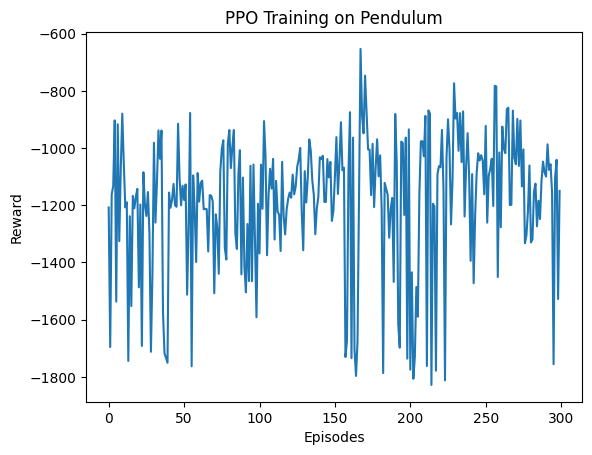

In [ ]:
plt.plot(scores)
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.title("PPO Training on Pendulum")
plt.show()

In [ ]:
env = gym.make("Pendulum-v1", render_mode="human")

state, _ = env.reset()
total_reward = 0

while True:
    action, _, _ = agent.select_action(state, action_low, action_high)
    state, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward

    if terminated or truncated:
        break

print("Evaluation Reward:", total_reward)
env.close()

Evaluation Reward: -997.123317169643
